In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [49]:
p = 200
n = 3000

In [50]:
X = np.random.normal(size=(p,n))

In [51]:
Yn = (1 / n) * (X @ X.T)

In [52]:
eigvals = np.linalg.eigvalsh(Yn)
eig_nonzero = eigvals[eigvals > 1e-12]

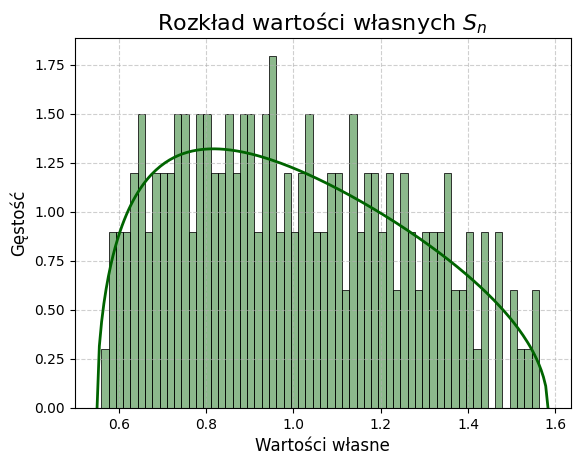

In [53]:
c = p/n
lambda_plus = (1+np.sqrt(c))**2
lambda_minus = (1-np.sqrt(c))**2
x = np.linspace(lambda_minus, lambda_plus, p)
dv = np.sqrt((lambda_plus - x)*(x - lambda_minus)) / (c*x * 2 *np.pi)

sns.histplot(eig_nonzero, bins = 60, kde=False, stat = "density", color = "darkgreen", alpha = 0.45)
plt.plot(x, dv, linewidth = 2, label = "Marchenko-Pastur gestosc", color = "darkgreen")
plt.xlabel("Wartości własne", fontsize = 12)
plt.ylabel("Gęstość", fontsize = 12)
plt.title(r"Rozkład wartości własnych $S_n$", fontsize = 16)
#plt.legend()
plt.grid(True, linestyle = "--", alpha = 0.6)
plt.savefig("wykres_wwSn_diag2_nlessp")
plt.show()

In [24]:
q = m/n
p = 18.99
gamma = 1

licznik1 = p*(gamma**2*m*q**2*(3*gamma - 1) + m*p**2*(3*gamma*p+3*gamma-p-1))
licznik2 = p*(q*(3*gamma**2*m*p**2+6*gamma**2*m*p-gamma*m*p**2 - 2*gamma*m*p +np.sqrt((gamma*m**2*(3*gamma-1)*(m*p+q*(gamma*m-3*gamma*p + p))*(gamma*q+p**2+p))/q**2)*(gamma*q+p)))
mianownik = m*(gamma*q+p)*(gamma**2*q**2*(3*gamma-1) + gamma*p*q*(3*gamma*p+6*gamma-p-2) + p**2*(3*gamma*p+3*gamma-p-1))


kopt = int((licznik1 + licznik2)/mianownik)
kopt

NameError: name 'm' is not defined

In [58]:
kopt = int(0.1 * n)
kopt

300

In [59]:
X1 = X[:, :kopt]
X2 = X[:, kopt:]

In [60]:
Sigma1 = 1/(kopt) * (X1@X1.T)
Sigma2 = 1/(n-kopt) * (X2@X2.T)
Sigmacale = 1/(n) * (X@X.T)

In [61]:
eigvals, P = np.linalg.eigh(Sigmacale)
eigvals1, P1 = np.linalg.eigh(Sigma1)

In [62]:
M = P1.T @ Sigma2 @ P1
D = np.diag(np.diag(M))
EST = P1 @ D @ P1.T

eigvalEST = np.linalg.eigvalsh(EST)
eigvalEST_nonzero = eigvalEST[eigvalEST > 1e-12]


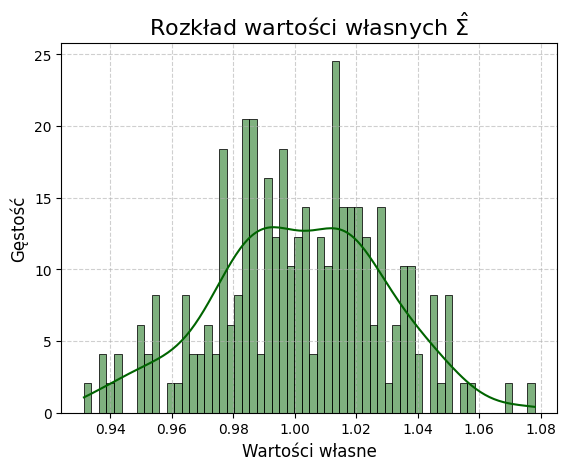

In [63]:
c = p/n
lambda_plus = (1+np.sqrt(c))**2
lambda_minus = (1-np.sqrt(c))**2
x = np.linspace(lambda_minus, lambda_plus, p)
dv = np.sqrt((lambda_plus - x)*(x - lambda_minus)) / (c*x * 2 *np.pi)

sns.histplot(eigvalEST_nonzero, bins=60, kde=True, stat="density", color = "darkgreen")
plt.xlabel("Wartości własne", fontsize = 12)
plt.ylabel("Gęstość", fontsize = 12)
plt.title(r"Rozkład wartości własnych $\hat{\Sigma}$", fontsize = 16)
plt.grid(True, linestyle = "--", alpha = 0.6)
plt.savefig("wykres_wwEST_diag2_nlessp")
plt.show()

In [64]:
Sigma_true = np.eye(p)
#1. Estymator standardowy (norma Frobeniusa)
np.linalg.norm(Yn - Sigma_true, ord = "fro")

3.6340544573905245

In [65]:
np.linalg.norm(EST - Sigma_true, ord = "fro")

0.38908293542815864

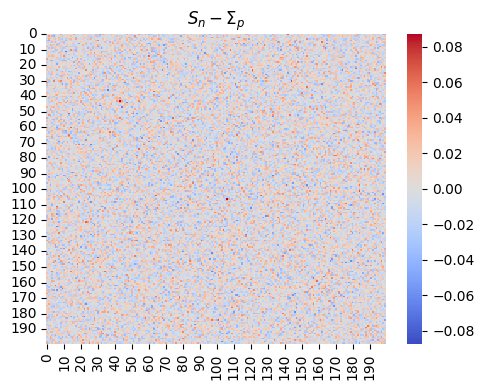

In [66]:
subset = 200

diff_EST = EST - Sigma_true
diff_Sn = Yn - Sigma_true

diff_EST_small = diff_EST[:subset, :subset]
diff_Sn_small = diff_Sn[:subset, :subset]

vmax = max(
    np.abs(diff_EST_small).max(),
    np.abs(diff_Sn_small).max()
)

fig, ax = plt.subplots(figsize=(5,4))

sns.heatmap(diff_Sn_small,
            ax=ax,
            cmap="coolwarm",
            vmin=-vmax,
            vmax=vmax,
            center=0)

ax.set_title(r"$S_n - \Sigma_{p}$")

#sns.heatmap(diff_EST_small,
#            ax=axes[1],
#            cmap="coolwarm",
#            vmin=-vmax,
#            vmax=vmax,
#            center=0)

#axes[1].set_title(r"$\hat{\Sigma} - \Sigma_{p}$")

plt.tight_layout()
plt.savefig("heatmap_diag2_nggp_poj")
plt.show()

In [61]:
diff_Sn[1650:subset, 1650:subset]

array([[ 0.03517226, -0.09966475,  0.00900367, ...,  0.00101901,
        -0.01598293, -0.07870708],
       [-0.09966475,  0.0093963 , -0.03316803, ...,  0.07773363,
         0.04153664, -0.06950654],
       [ 0.00900367, -0.03316803, -0.14488849, ..., -0.02248938,
         0.01719128, -0.00763576],
       ...,
       [ 0.00101901,  0.07773363, -0.02248938, ..., -0.03016806,
         0.08825738,  0.06493627],
       [-0.01598293,  0.04153664,  0.01719128, ...,  0.08825738,
        -0.07155227,  0.00406313],
       [-0.07870708, -0.06950654, -0.00763576, ...,  0.06493627,
         0.00406313, -0.10696987]])